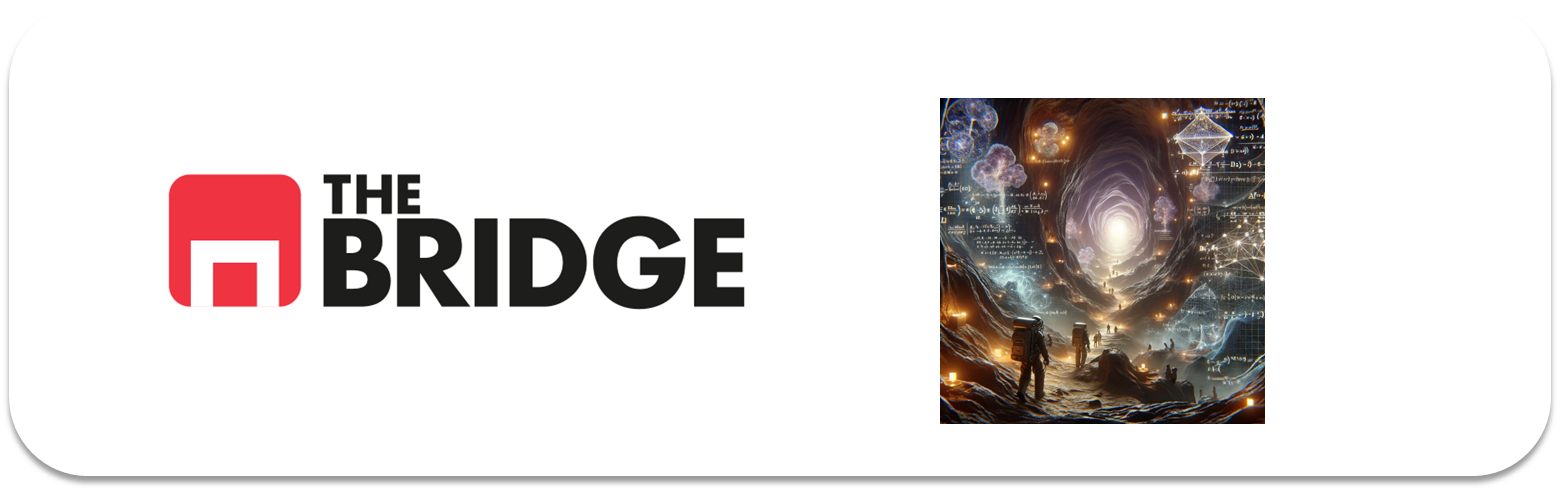

## PRACTICA OBLIGATORIA: **Introducción Deep Learning**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de modelado del dataset del titanic empleando y comparando dos modelos diferentes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [247]:
import bootcampviztools as bt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, ConfusionMatrixDisplay

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    FunctionTransformer,
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler
)


### Descripción y objetivo

El objetivo de la práctica es crear un modelo DL y compararlo con un modelo Random Forest para el dataset de titanic los dos con el mismo objetivo, predecir la supervivencia de un pasajero.  Se pide:  
1. Desarrollar el proceso de ML hasta crear los dos modelos DL y Random Forest. El primero debe tener una topología MLP (es decir una red densa) con un máximo de 3 capas ocultas y debes emplear sklearn para crearlo. No es necesario hacer una análisis/seleccion exahustivo. Escoge una métrica acorde al tipo de target del problema. 

2. Ambos modelos deben tener sus hiperparámetros optimizados, mediante GridSearch. Para ello: utiliza el grid de parámetros que creas conveniente para Random Forest y para el modelo DL, utiliza un grid con los hiperparámetros siguientes:'hidden_layer_sizes','activation', 'solver','alpha' y 'learning_rate'. Para los rangos del grid del modelo de DL guíate por lo visto en el workout y por los posibles valores que se indican en la [documentación](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html#sklearn.neural_network.MLPClassifier). Prueba por lo menos una topología con una sola capa oculta y otra con más de una capa oculta.   
NOTA: Incluye los valores por defecto de los hiperparámetros escogidos en cada caso dentro del grid de hiperparámetros. 
  

3. Compara los modelos respecto a sus métricas medias de accuracy, precision, recall y tiempos de entrenamiento (para ello tendrás que realizar un entrenamiento a parte del mejor modelo obtenido en la optimización de hiperparámetros) y decide cuál te quedarías argumentándolo.    

4. Para el mejor modelo DL obtenido, muestra su clasification report, y la matriz de confusión comentando el resultado.


### **Exploración inicial:**


In [188]:
df_titanic = pd.read_csv("./data/titanic.csv")

In [189]:
df = df_titanic.copy()

In [190]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 116.9 KB


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [191]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [192]:
df = df.drop(columns=["deck", "embark_town", "alive", "adult_male", "who", "class"])

### **Split de train y test**

In [193]:
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

### **Imputación de valores previa al mini-EDA**

In [195]:
age_imputer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

embarked_imputer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

train_set = train_set.copy()
test_set = test_set.copy()

train_set["age"] = age_imputer.fit_transform(train_set[["age"]]).ravel()
test_set["age"] = age_imputer.transform(test_set[["age"]]).ravel()

train_set["embarked"] = embarked_imputer.fit_transform(train_set[["embarked"]]).ravel()
test_set["embarked"] = embarked_imputer.transform(test_set[["embarked"]]).ravel()

### **Mini-EDA:**

In [196]:
features = list(train_set.columns)
cols_cat = [col for col in features if col not in ["age", "fare", "survived"]]
cols_num = ["age", "fare"]
target = "survived"
features.remove(target)

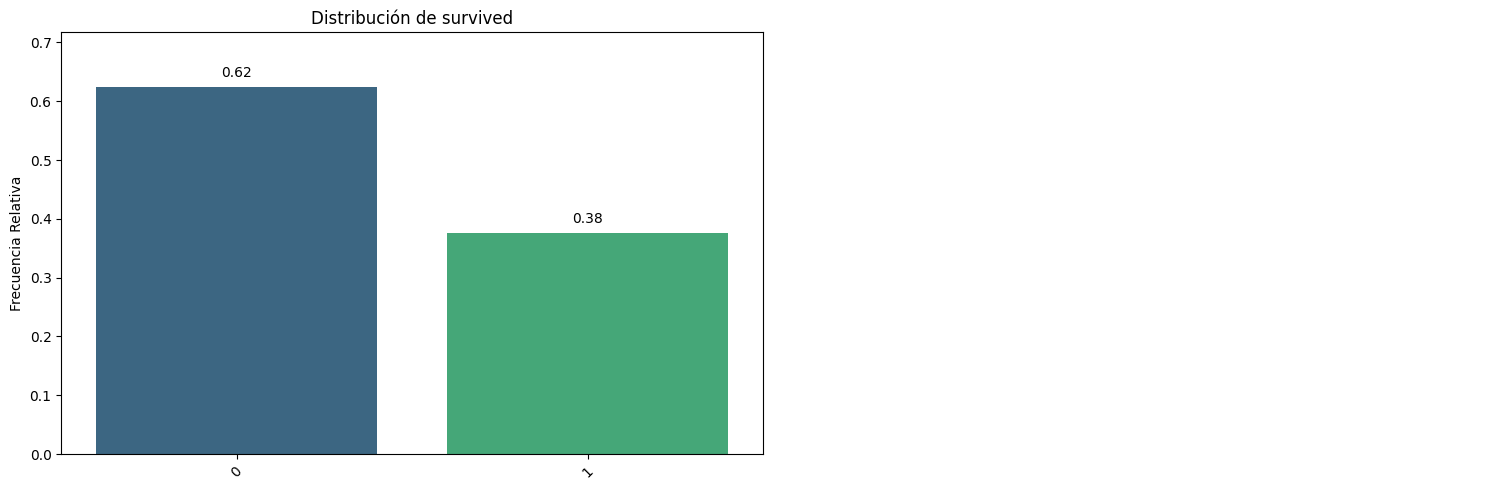

In [197]:
bt.pinta_distribucion_categoricas(train_set, [target], relativa=True, mostrar_valores=True)

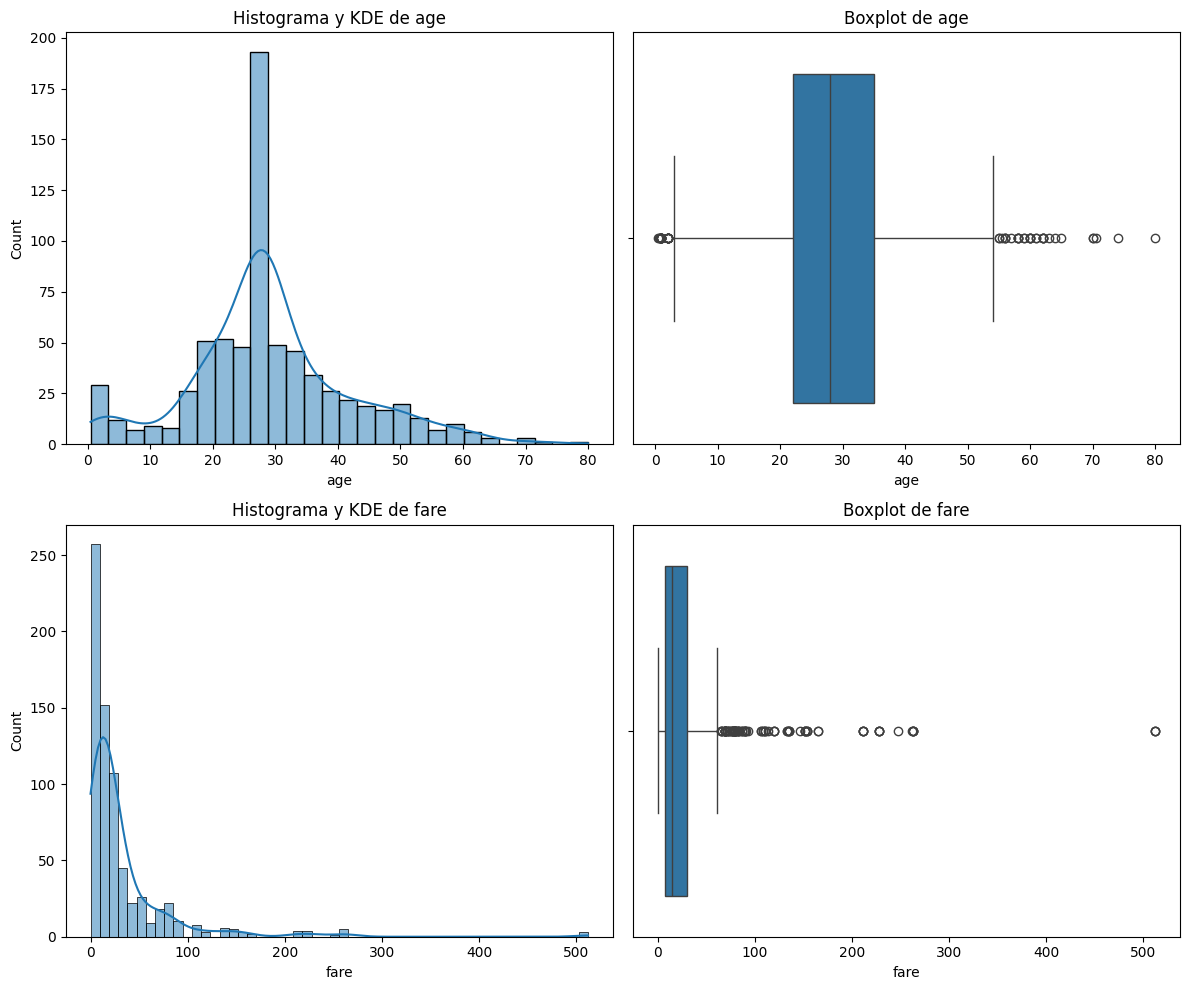

In [198]:
bt.plot_combined_graphs(train_set, cols_num)

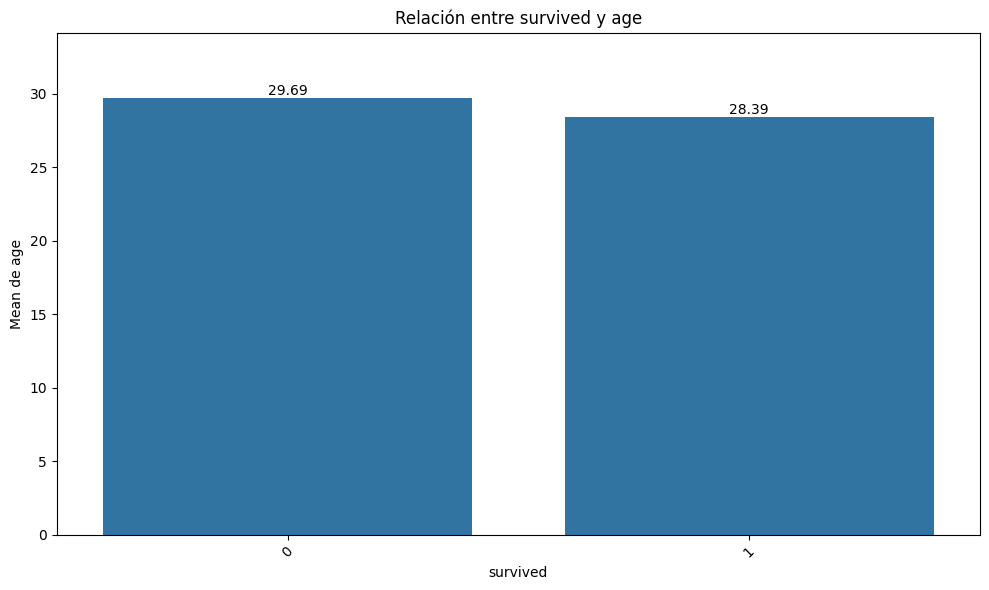

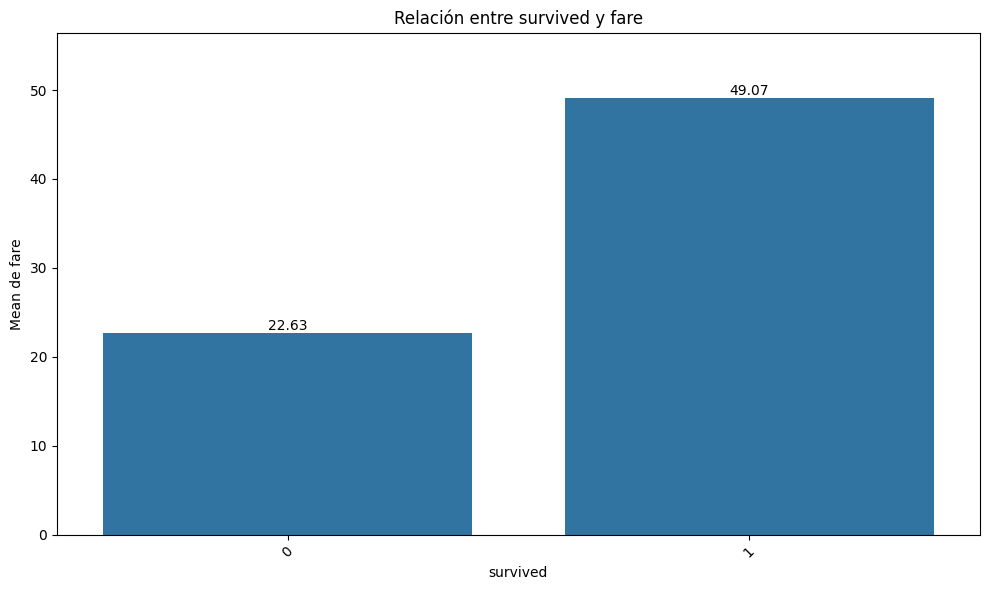

In [199]:
for col in cols_num:
    bt.plot_categorical_numerical_relationship(train_set, target, col, show_values=True)

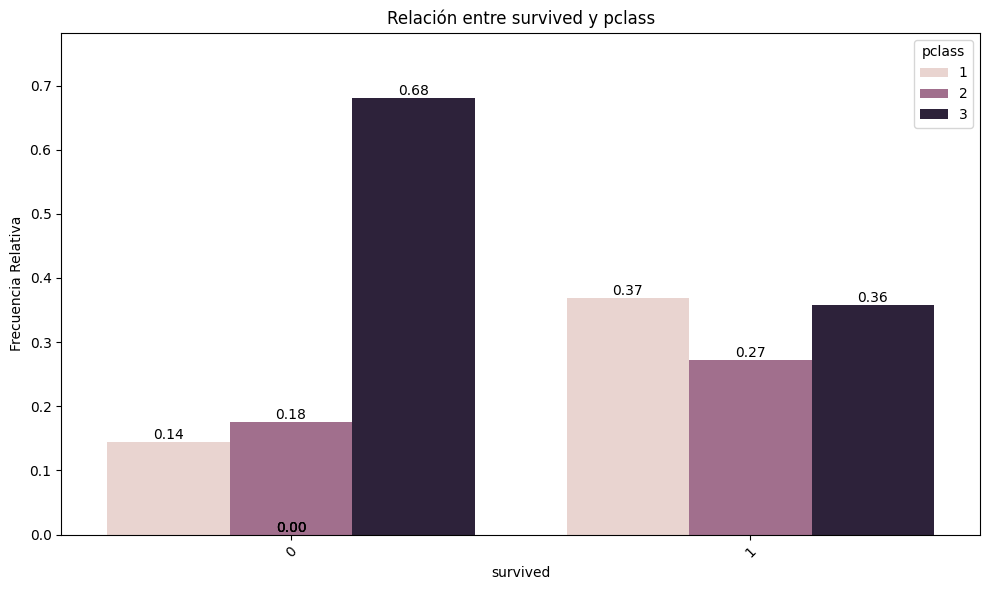

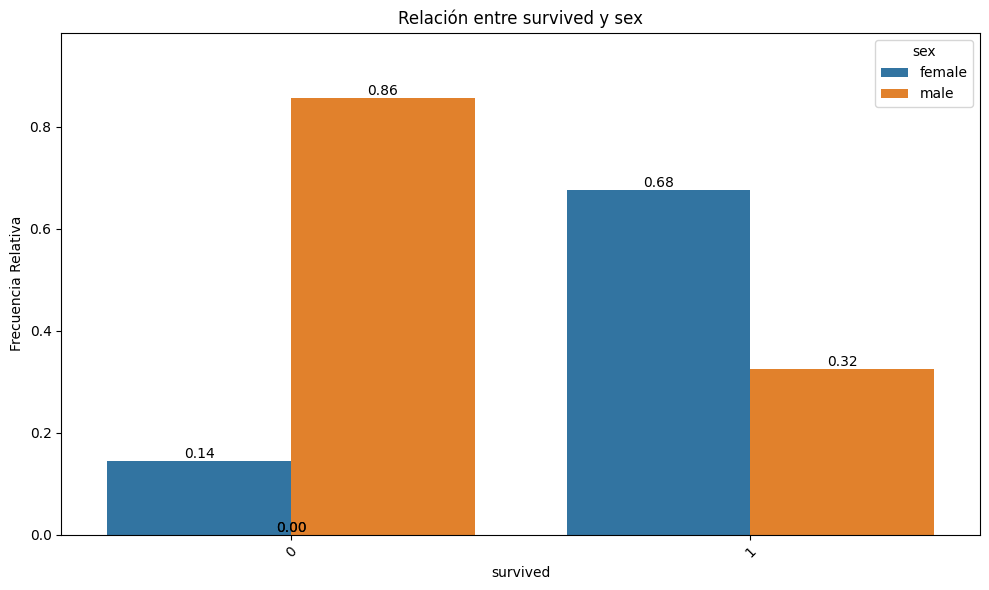

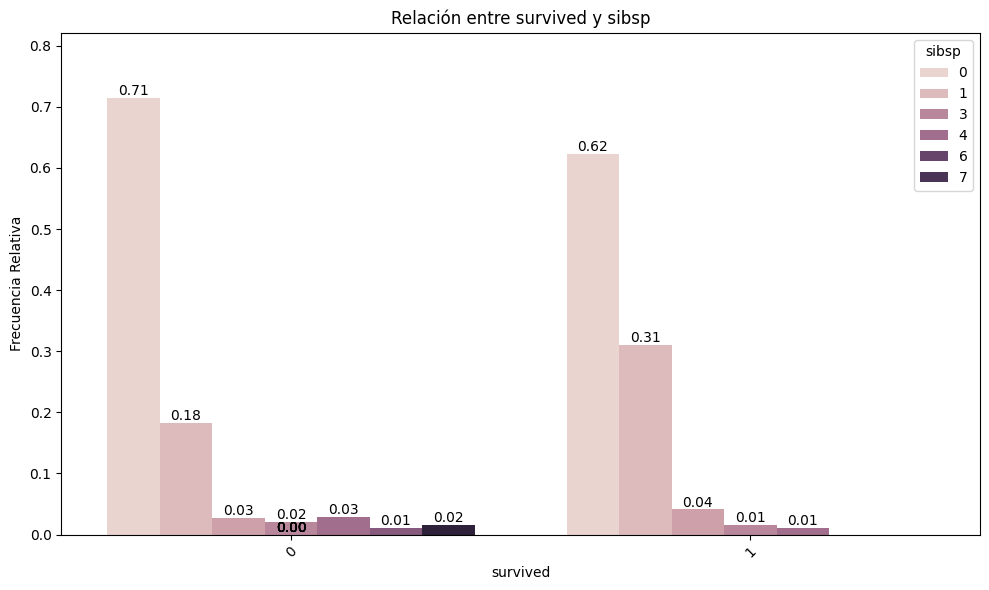

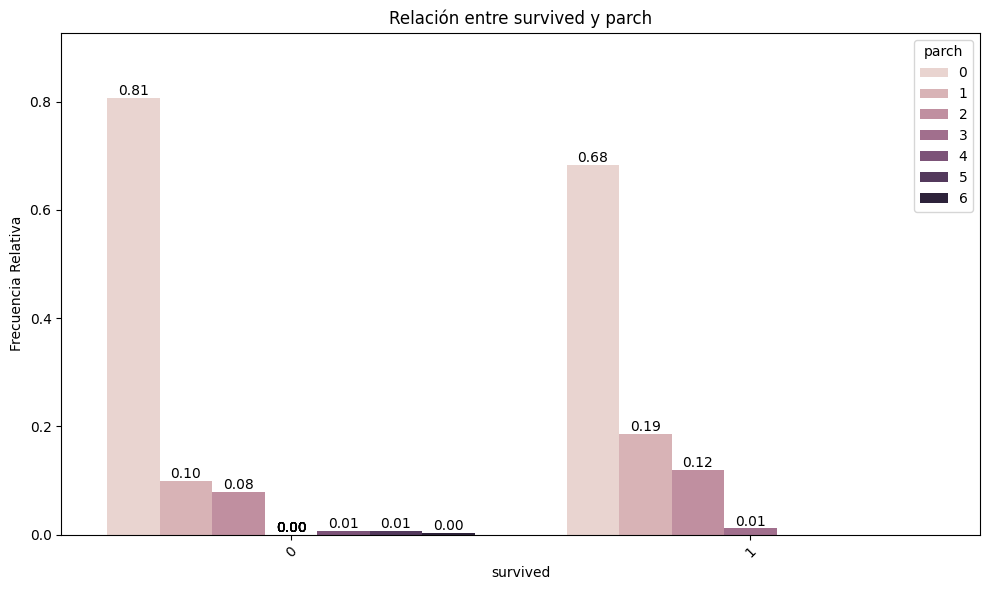

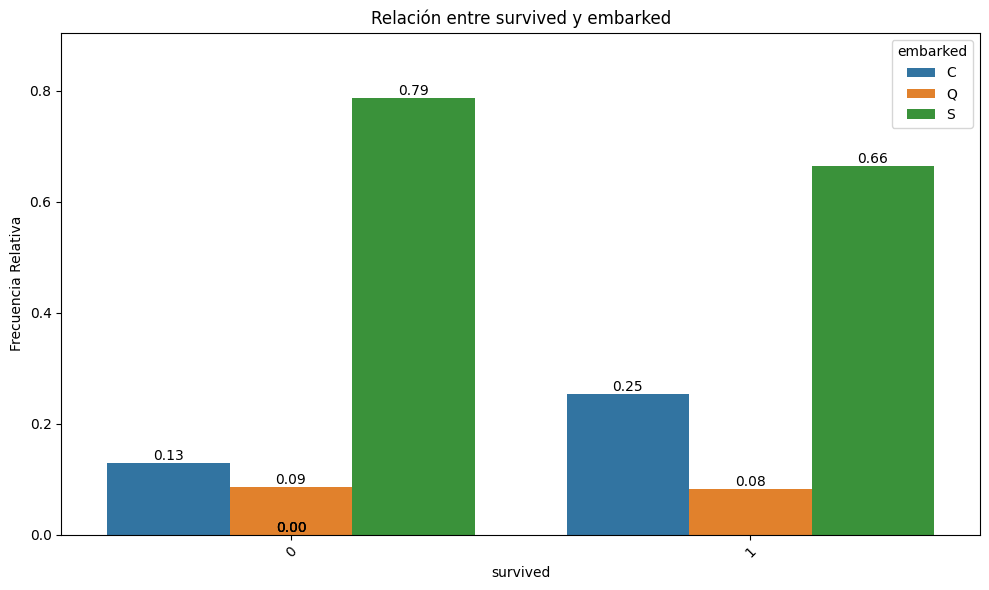

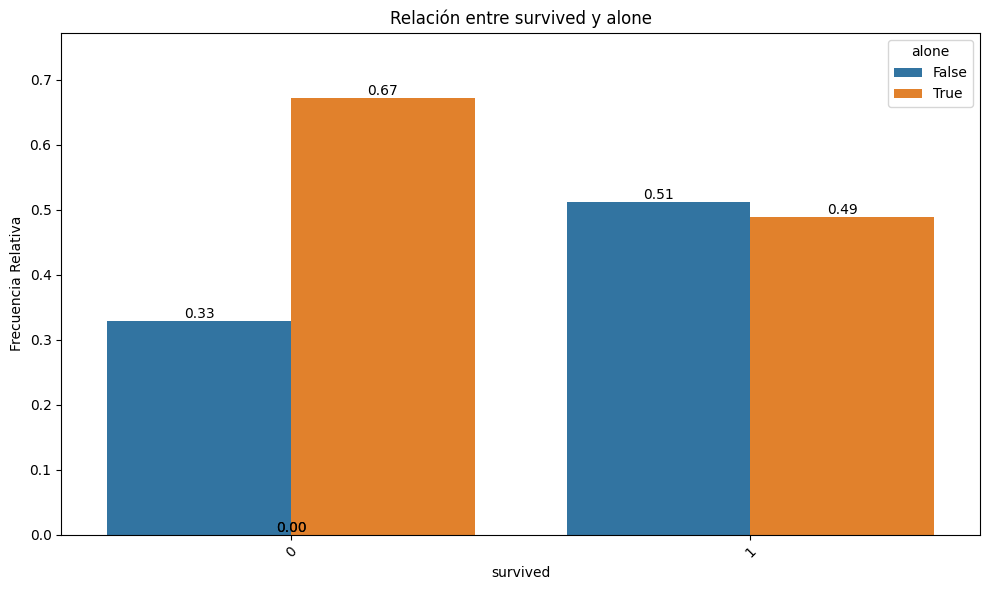

In [200]:
for col in cols_cat:
    bt.plot_categorical_relationship(train_set, target, col, relative_freq=True, show_values=True)

- `age` no muestra tener una inferencia significativa con respecto a la variable target.
- Necesidad de aplicar escala logarítmica a `fare` debido a distribución de sus valores.
- `pclass` muestra tener relación con respecto al target. No necesita transformación de sus valores.
- OrdinalEncoder para `sex`. Muestra tener relación con la variable target.
- `sibsp` y `parch` se procede a combinarlas en una sola variable denominada `family_size`
- Encontramos cierta relación en `embarked`. Se aplica OneHotEncoder.
- `alone` muestra tener relación. Se transforma de bool a numérica (0 y 1).

### **Determinación de X e y**

In [201]:
X_train = train_set[features]
y_train = train_set[target]

X_test = test_set[features]
y_test = test_set[target]

### **Preporcesado**

La imputación de valores nulos se realizó previamente, siguiendo la regla de oro (ajustando los imputadores únicamente sobre el conjunto de entrenamiento). Posteriormente, se construyó un pipeline encargado del resto de transformaciones del preprocesado

In [203]:
X_train["family_size"] = X_train["sibsp"] + X_train["parch"] + 1
X_test["family_size"] = X_test["sibsp"] + X_test["parch"] + 1

X_train.drop(columns=["sibsp", "parch"], inplace=True)
X_test.drop(columns=["sibsp", "parch"], inplace=True)

In [205]:
categorical_nominal = ["embarked"]

categorical_ordinal = ["sex"]

numeric_log = ["fare"]

boolean_cols = ["alone"]

preprocessor = ColumnTransformer(
    transformers=[
        ("fare", FunctionTransformer(np.log1p), numeric_log),

        ("sex", OrdinalEncoder(), categorical_ordinal),

        ("embarked",
         OneHotEncoder(handle_unknown="ignore",
                       sparse_output=False),
         categorical_nominal),

        ("alone",
         FunctionTransformer(lambda x: x.astype(int),
                             validate=False),
         boolean_cols),
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
)

In [206]:
preprocessor.set_output(transform="pandas")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('fare', ...), ('sex', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

In [207]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [209]:
X_test.head()

,fare,sex,embarked_C,embarked_Q,embarked_S,alone,pclass,age,family_size
709,2.787834,1.0,1.0,0.0,0.0,0,3,28.0,3
439,2.442347,1.0,0.0,0.0,1.0,1,2,31.0,1
840,2.188856,1.0,0.0,0.0,1.0,1,3,20.0,1
720,3.526361,0.0,0.0,0.0,1.0,0,2,6.0,2
39,2.504848,0.0,1.0,0.0,0.0,0,3,14.0,2


In [212]:
scaler = StandardScaler()

X_train_sc = X_train.copy()
X_test_sc = X_test.copy()

X_train_sc[["fare", "pclass", "age", "family_size"]] = scaler.fit_transform(X_train[["fare", "pclass", "age", "family_size"]])
X_test_sc[["fare", "pclass", "age", "family_size"]] = scaler.transform(X_test[["fare", "pclass", "age", "family_size"]])


In [213]:
X_train_sc.head()

,fare,sex,embarked_C,embarked_Q,embarked_S,alone,pclass,age,family_size
331,0.437404,1.0,0.0,0.0,1.0,1,-1.614136,1.253641,-0.554666
733,-0.322935,1.0,0.0,0.0,1.0,1,-0.400551,-0.477284,-0.554666
382,-0.782201,1.0,0.0,0.0,1.0,1,0.813034,0.215086,-0.554666
704,-0.790325,1.0,0.0,0.0,1.0,0,0.813034,-0.246494,0.040096
813,0.529116,0.0,0.0,0.0,1.0,0,0.813034,-1.785093,3.013909


### **Entrenamiento de modelos baseline**

##### MLP Classifier (DL)

In [222]:
mlp = MLPClassifier(max_iter=800, random_state=42,  hidden_layer_sizes = (64, 32, 16)) 

In [223]:
mlp.fit(X_train_sc, y_train)

print(mlp.score(X_train_sc, y_train))
print(mlp.score(X_test_sc, y_test))

0.8918539325842697
0.8156424581005587


##### Random Forest Classifier

In [230]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_leaf=5,
    random_state=42
)

In [231]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [232]:
y_pred_train = rf.predict(X_train)
y_pred_test = rf.predict(X_test)

print(f"Accuracy RF train: {accuracy_score(y_train, y_pred_train)}")
print(f"Accuracy RF test: {accuracy_score(y_test, y_pred_test)}")

Accuracy RF train: 0.8539325842696629
Accuracy RF test: 0.8100558659217877


### **Optimización de hiperparámetros**

##### Optimización MLP Classifier

In [233]:
param_grid_mlp = {
    "hidden_layer_sizes": [
        (100,),          # valor por defecto
        (64,),
        (64, 32),
        (64, 32, 16)
    ],
    "activation": [
        "relu",          # valor por defecto
        "tanh",
        "logistic"
    ],
    "solver": [
        "adam",          # valor por defecto
        "sgd"
    ],
    "alpha": [
        0.0001,          # valor por defecto
        0.001,
        0.01
    ],
    "learning_rate": [
        "constant",      # valor por defecto
        "adaptive"
    ]
}

In [238]:
grid_mlp = GridSearchCV(
    MLPClassifier(
        max_iter=500,
        random_state=42
    ),
    param_grid=param_grid_mlp,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_mlp.fit(X_train_sc, y_train)

c:\Users\salit\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MLPClassifier...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'activation': ['relu', 'tanh', ...], 'alpha': [0.0001, 0.001, ...], 'hidden_layer_sizes': [(100,), (64,), ...], 'learning_rate': ['constant', 'adaptive'], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the c

##### Optimización Random Forest Classifier

In [235]:
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [236]:
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each 

### **Evaluación de modelos optimizados**

In [240]:
y_pred_mlp_opt = grid_mlp.predict(X_test_sc)
y_pred_rf_opt = grid_rf.predict(X_test)

resultados = pd.DataFrame({
    "Modelo": ["Random Forest", "MLP"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf_opt),
        accuracy_score(y_test, y_pred_mlp_opt)
    ],
    "Precision": [
        precision_score(y_test, y_pred_rf_opt),
        precision_score(y_test, y_pred_mlp_opt)
    ],
    "Recall": [
        recall_score(y_test, y_pred_rf_opt),
        recall_score(y_test, y_pred_mlp_opt)
    ]
})

resultados = resultados.round(5)

resultados

,Modelo,Accuracy,Precision,Recall
0,Random Forest,0.80447,0.80952,0.68919
1,MLP,0.78771,0.77273,0.68919


In [245]:
print(grid_rf.best_params_)
print(grid_rf.best_score_)

print(grid_mlp.best_params_)
print(grid_mlp.best_score_)

{'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
0.8342263370432385
{'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (100,), 'learning_rate': 'constant', 'solver': 'adam'}
0.813158672313602


### **Elección final del modelo y conclusiones**

El modelo seleccionado finalmente para este problema es Random Forest Classifier.

- Presenta un mejor rendimiento en las métricas de accuracy y precisión, manteniendo el mismo valor de recall que el modelo MLP optimizado.
- El proceso de optimización de hiperparámetros fue más eficiente en términos de tiempo, completándose en 1 minuto y 34 segundos, frente a los 3 minutos y 25 segundos necesarios para optimizar el modelo MLP.

En conjunto, Random Forest ofrece un mejor equilibrio entre rendimiento predictivo y coste computacional. A pesar de que MLP pertenece a la familia de modelos de Deep Learning, en este problema concreto Random Forest demuestra una mayor capacidad de generalización con un tiempo de entrenamiento significativamente inferior, por lo que se considera la alternativa más adecuada.

### **Representación de classification_report y Matriz de Confusión**

              precision    recall  f1-score   support

           0       0.80      0.89      0.84       105
           1       0.81      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



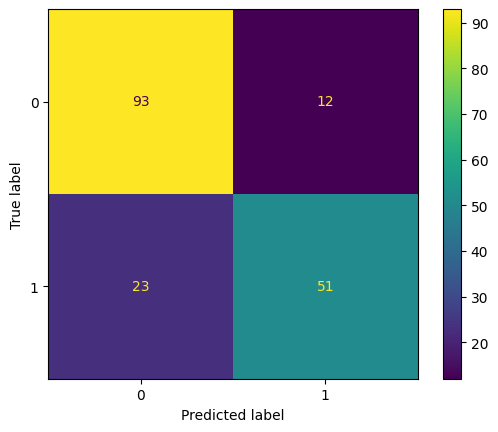

In [249]:
print(classification_report(y_test, y_pred_rf_opt))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf_opt);